# Custom Symbolic Expression with `CustomSymbolGenerator`

Unlike [`SeriesSymbolGenerator`](https://github.com/wwhenxuan/S2Generator/blob/main/s2generator/symbol/generators.py), which **randomly** constructs complex systems $f(\cdot)$, [`CustomSymbolGenerator`](https://github.com/wwhenxuan/S2Generator/blob/main/s2generator/symbol/generators.py) lets you **bind a user-specified** symbolic expression and then sample excitation series $X$ through the excitation module to obtain the response:

$$
Y = f(X).
$$

Supported expression formats:

- **Infix** (same style as printed by `Node.infix()`), e.g. `(x_0 add sin(x_0))`
- **Prefix** (comma-separated), e.g. `add,x_0,sin,x_0`
- Multi-output systems joined by `|`, e.g. `(x_0 add 1) | sin(x_1)`
- Existing `Node` / `NodeList` objects

Below we demonstrate how to use this interface.

In [2]:
import sys
from pathlib import Path

import numpy as np

# Make the project importable when the notebook is opened from examples/symbol/
# (or from the repo root / examples/).
for _candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (_candidate / "s2generator").is_dir():
        sys.path.insert(0, str(_candidate.resolve()))
        break

from s2generator.symbol import (
    CustomSymbolGenerator,
    SeriesSymbolGenerator,
    SeriesParams,
    SymbolParams,
    parse_symbol,
)
from s2generator.utils import plot_symbol_series, plot_symbol
from s2generator import print_hello

print_hello()

Hello, S2Generator!
Version: 0.0.15
This is a Python package for generating time series data with symbolic representations.
For more information, please visit: https://github.com/wwhenxuan/S2Generator

   _____   ___     _____                                        _                  
  / ____| |__ \   / ____|                                      | |                 
 | (___      ) | | |  __    ___   _ __     ___   _ __    __ _  | |_    ___    _ __ 
  \___ \    / /  | | |_ |  / _ \ | '_ \   / _ \ | '__|  / _` | | __|  / _ \  | '__|
  ____) |  / /_  | |__| | |  __/ | | | | |  __/ | |    | (_| | | |_  | (_) | | |   
 |_____/  |____|  \_____|  \___| |_| |_|  \___| |_|     \__,_|  \__|  \___/  |_|                                   



## 1. Bind a Simple Univariate System

We first specify a fixed complex system

$$
f(x_0) = x_0 + \sin(x_0),
$$

create a `CustomSymbolGenerator`, and generate excitation / response series with `run`.
Input and output dimensions are inferred automatically from the expression.

Bound symbol: (x_0 add sin(x_0))
Inferred input dimension: 1
Inferred output dimension: 1
Excitation shape: (256, 1)
Response shape: (256, 1)


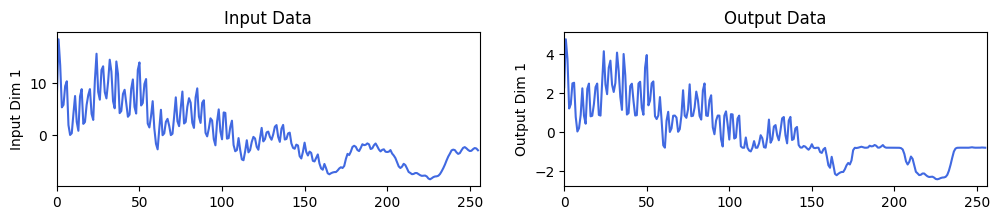

In [3]:
# Bind a user-specified complex system (infix form)
custom = CustomSymbolGenerator("(x_0 add sin(x_0))")

print("Bound symbol:", custom.symbol)
print("Inferred input dimension:", custom.input_dimension)
print("Inferred output dimension:", custom.output_dimension)

rng = np.random.RandomState(0)

# Sample excitation X via the excitation module, then evaluate Y = f(X)
symbol, inputs, outputs = custom.run(rng, n_inputs_points=256)

print("Excitation shape:", inputs.shape)
print("Response shape:", outputs.shape)

fig = plot_symbol_series(inputs, outputs)

We can also visualize the symbolic expression itself:

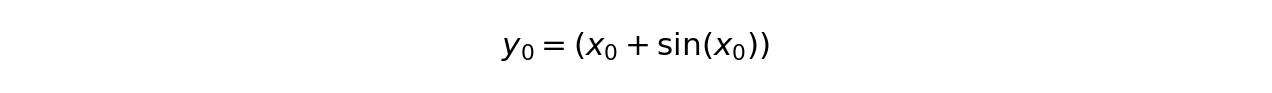

In [4]:
fig = plot_symbol(symbol, width=10)

## 2. Multi-Output Symbolic Systems

Multiple output channels can be joined by `|`. For example:

$$
\begin{aligned}
y_0 &= x_0 \cdot \cos(x_0), \\
y_1 &= x_0 + 1.
\end{aligned}
$$

Each expression on one side of `|` corresponds to one output dimension.

Bound symbol: (x_0 mul cos(x_0)) | (x_0 add 1)
Input dim: 1 | Output dim: 2
Excitation shape: (256, 1)
Response shape: (256, 2)


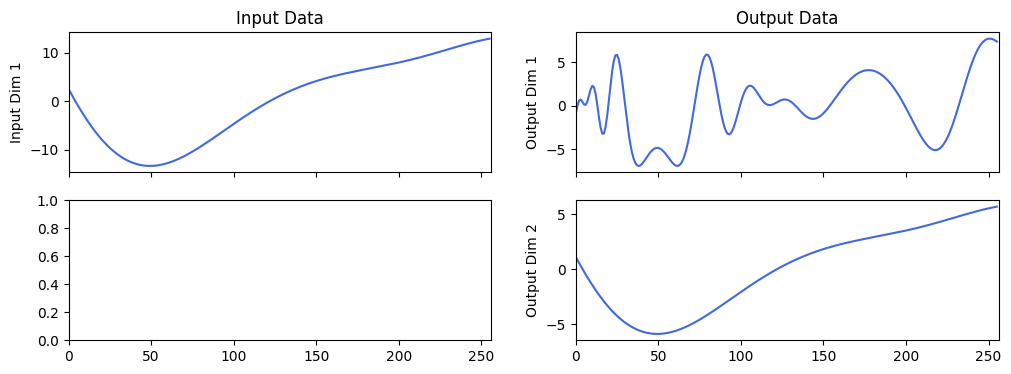

In [10]:
custom_multi = CustomSymbolGenerator("(x_0 mul cos(x_0)) | (x_0 add 1)")

print("Bound symbol:", custom_multi.symbol)
print(
    "Input dim:",
    custom_multi.input_dimension,
    "| Output dim:",
    custom_multi.output_dimension,
)

symbol, inputs, outputs = custom_multi.run(
    np.random.RandomState(8), n_inputs_points=256
)

print("Excitation shape:", inputs.shape)
print("Response shape:", outputs.shape)

fig = plot_symbol_series(inputs, outputs)

## 3. Prefix Form and Multivariate Inputs

Besides infix strings, you can pass a **prefix** token stream (comma-separated).
Variables `x_0`, `x_1`, ... determine the required input dimension.

Here we use

$$
f(x_0, x_1) = x_0 + 2 x_1,
$$

written in prefix form as `add,x_0,mul,2,x_1`.

Infix view: (x_0 add (2 mul x_1))
Prefix view: add,x_0,mul,2,x_1
Input dim: 2
Excitation shape: (256, 2)
Response shape: (256, 1)


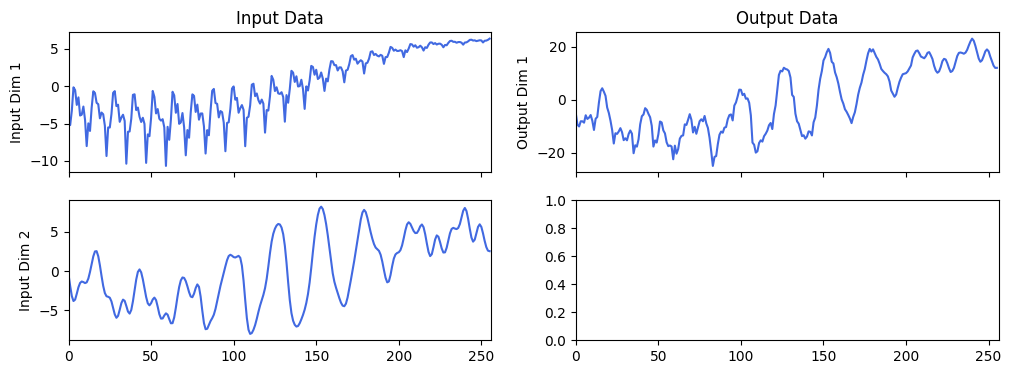

In [6]:
custom_prefix = CustomSymbolGenerator("add,x_0,mul,2,x_1")

print("Infix view:", custom_prefix.symbol.infix())
print("Prefix view:", custom_prefix.symbol.prefix())
print("Input dim:", custom_prefix.input_dimension)

symbol, inputs, outputs = custom_prefix.run(
    np.random.RandomState(3), n_inputs_points=256
)

print("Excitation shape:", inputs.shape)
print("Response shape:", outputs.shape)

fig = plot_symbol_series(inputs, outputs)

## 4. Control Excitation Sampling with `SeriesParams`

`CustomSymbolGenerator` reuses the excitation module. You can pass a `SeriesParams`
object to bias which excitation methods are used (MixedDistribution, ARMA, ForecastPFN, KernelSynth, IMF, etc.).

Bound symbol: ((x_0 mul exp((-0.1 mul x_0))) add sin((2 mul x_0)))


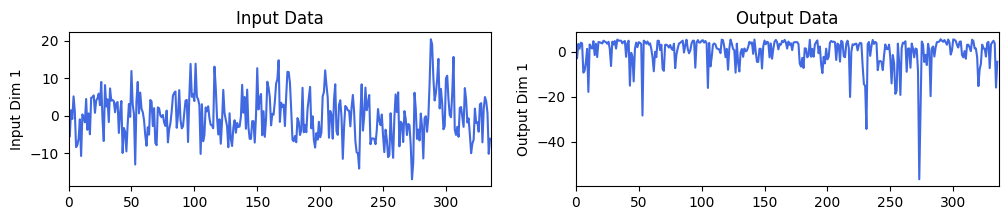

In [7]:
# Prefer ARMA / ForecastPFN style excitations for this custom system
series_params = SeriesParams(
    mixed_distribution=0.1,
    autoregressive_moving_average=0.4,
    forecast_pfn=0.3,
    kernel_synth=0.1,
    intrinsic_mode_function=0.1,
)

expr = "((x_0 mul exp((-0.1 mul x_0))) add sin((2 mul x_0)))"
custom_ctrl = CustomSymbolGenerator(
    symbol=expr,
    series_params=series_params,
    symbol_params=SymbolParams(max_trials=64),
)

print("Bound symbol:", custom_ctrl.symbol)

symbol, inputs, outputs = custom_ctrl.run(
    np.random.RandomState(42),
    n_inputs_points=336,
    input_normalize="z-score",
    output_normalize="z-score",
)

fig = plot_symbol_series(inputs, outputs)

## 5. Alternative: `SeriesSymbolGenerator.run_from_symbol`

If you do not want a dedicated object, you can also call `run_from_symbol` on
`SeriesSymbolGenerator`, or use `parse_symbol` to inspect / reuse a parsed tree.

Parsed infix: (x_0 add log((1 add abs(x_0)))) | cos(x_0)
Parsed prefix: add,x_0,log,add,1,abs,x_0,|,cos,x_0


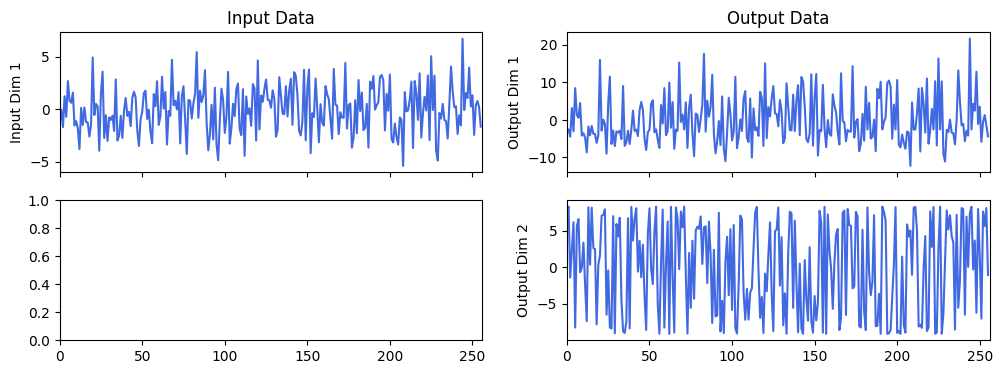

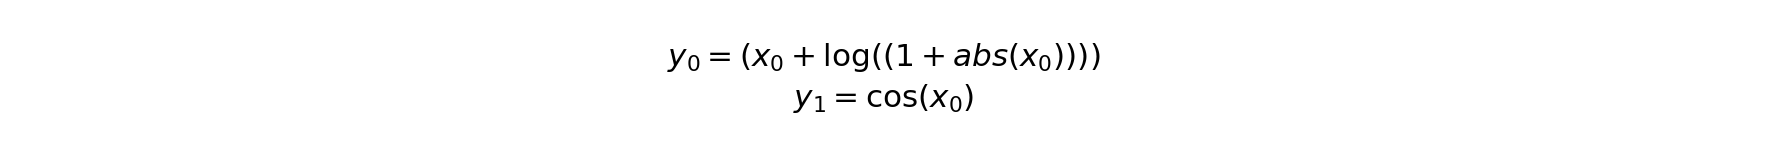

In [8]:
# Parse first (useful for inspection or reuse)
trees = parse_symbol("(x_0 add log((1 add abs(x_0)))) | cos(x_0)")
print("Parsed infix:", trees.infix())
print("Parsed prefix:", trees.prefix())

# Or generate directly through SeriesSymbolGenerator
generator = SeriesSymbolGenerator()
symbol, inputs, outputs = generator.run_from_symbol(
    np.random.RandomState(11),
    symbol=trees,  # infix / prefix strings are also accepted
    n_inputs_points=256,
)

fig = plot_symbol_series(inputs, outputs)
_ = plot_symbol(symbol, width=14)

## 6. Validate Expressions with Precise Errors

Before binding a custom system, you can call `check_symbol` / `explain_symbol_error`.
Invalid inputs raise **specific** exception types (not a generic `ValueError`), each with a `hint` telling you how to fix the expression.

In [9]:
from s2generator.symbol import (
    check_symbol,
    is_valid_symbol,
    explain_symbol_error,
    InvalidBinaryFormError,
    TrailingTokensError,
    UnbalancedParenthesesError,
    PrefixArityError,
)

# Valid expression
print("valid?", is_valid_symbol("(x_0 add sin(x_0))"))
print("parsed:", check_symbol("(x_0 add sin(x_0))").prefix())

# Inspect several common mistakes without crashing the notebook
bad_cases = [
    "(x_0 + 1)",  # calculator '+' instead of 'add'
    "(x_0 add sin(x_0)",  # missing ')'
    "(x_0 mul 2) add sin(x_0)",  # missing outer parentheses
    "add,x_0",  # prefix arity error
    "sinn(x_0)",  # typo
    "sin(1)",  # no variable x_i
]

for expr in bad_cases:
    err = explain_symbol_error(expr)
    print("-" * 60)
    print("expr:", expr)
    print("type:", type(err).__name__)
    print("msg :", err)

valid? True
parsed: add,x_0,sin,x_0
------------------------------------------------------------
expr: (x_0 + 1)
type: InvalidBinaryFormError
msg : Unsupported operator syntax '+'. | token='+' | position=5 | expression='(x_0 + 1)' | hint: use the word operator 'add' inside parentheses, e.g. '(x_0 add 1)'
------------------------------------------------------------
expr: (x_0 add sin(x_0)
type: UnbalancedParenthesesError
msg : Unclosed parenthesis: 1 '(' left open. | token='(' | position=16 | expression='(x_0 add sin(x_0)' | hint: add the missing ')' at the end of the corresponding sub-expression
------------------------------------------------------------
expr: (x_0 mul 2) add sin(x_0)
type: TrailingTokensError
msg : Unexpected trailing tokens after a complete expression. | token='add' | expression='(x_0 mul 2) add sin(x_0)' | hint: binary operators must be written as '(left op right)'; for example write '((x_0 mul 2) add sin(x_0))' instead of '(x_0 mul 2) add sin(x_0)'
---------------

## Summary

| API | Use case |
|---|---|
| `CustomSymbolGenerator(symbol)` | Bind a fixed $f(\cdot)$, then repeatedly call `run` |
| `SeriesSymbolGenerator.run_from_symbol(...)` | One-shot generation from a user expression |
| `parse_symbol(...)` | Convert infix / prefix / `Node` into a `NodeList` |
| `check_symbol(...)` / `explain_symbol_error(...)` | Validate user expressions with precise exceptions / hints |

Together with the excitation module, these interfaces make it easy to study the response of a **known** dynamical / symbolic system under diverse random excitations.